In [13]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder

from pathlib import Path


In [14]:
INPUT_PATH = Path("~/Research/AsTrovello/Input/").expanduser()
hst_suffix = "PHANGS-HST/galaxies/ngc1087/hlsp_phangs-hst_hst_wfc3-uvis_ngc1087_f814w_v1_exp-drc-sci.fits"
jwst_suffix = "PHANGS-JWST/galaxies/ngc1087/hlsp_phangs-jwst_jwst_nircam_ngc1087_f200w_v1p1_img.fits"

hst_file = INPUT_PATH / hst_suffix
jwst_file = INPUT_PATH / jwst_suffix


In [15]:
with fits.open(hst_file) as hdu_hst, fits.open(jwst_file) as hdu_jwst:
    data_hst = hdu_hst[0].data
    header_hst = hdu_hst[0].header
    
    data_jwst = hdu_jwst[1].data
    header_jwst = hdu_jwst[1].header
    

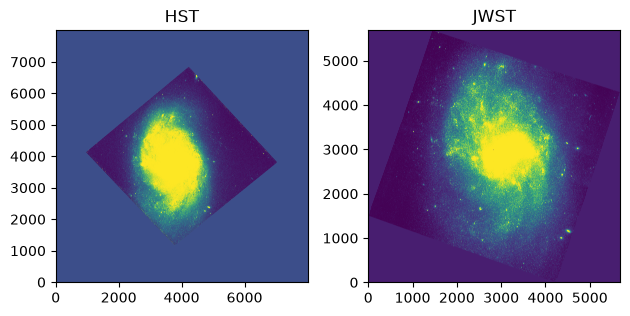

In [19]:
min_hst, max_hst = np.percentile(data_hst, [5, 95])
min_jwst, max_jwst = np.percentile(data_jwst, [5, 95])

fig, (ax1, ax2) = plt.subplots(1,2)
ax1.imshow(data_hst, cmap="viridis", origin="lower", vmin=min_hst, vmax=max_hst)
ax2.imshow(data_jwst, cmap="viridis", origin="lower", vmin=min_jwst, vmax=max_jwst)
ax1.set_title("HST")
ax2.set_title("JWST")
plt.tight_layout()
plt.show()


In [22]:
mean_hst, median_hst, std_hst = sigma_clipped_stats(data_hst, sigma=5.0, maxiters=5)
mean_jwst, median_jwst, std_jwst = sigma_clipped_stats(data_jwst, sigma=5.0, maxiters=5)

hst_dict = {"telescope": "HST", "mean": mean_hst, "median": median_hst, "std": std_hst}
jwst_dict = {"telescope": "JWST", "mean": mean_jwst, "median": median_jwst, "std": std_jwst}



In [24]:
for key in hst_dict:
    print(f"| {key}", end=" ")

| telescope | mean | median | std 